# Unsupervised – Data cleaning & EDA (patient testimonies)



This notebook covers the **unsupervised dataset ingestion, cleaning, and exploratory data analysis (EDA)** required by the CVRIE subject.

**Pipeline overview**: raw CSV → robust row parsing (optional color column) → length/stop-word/token EDA → normalised text → deduplication → `cleaned_unsupervised_dataset.csv` for notebook 02.

## Subject compliance reminders

- The dataset is **unlabeled**: we do **not** create labels.

- The `color` field (when present) is kept **only** for **visualization during defense** and is **never** used for vectorization/clustering.

- Cleaning is kept **transparent** and **retraceable**.


In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Stop words for EDA / vectorizers: sklearn English list + narrative fillers common in short first-person text
_EXTRA_STOPS = frozenset({"just", "really", "quite", "also", "though", "maybe", "somewhat", "bit", "even", "still"})
STOP_WORDS = sorted(frozenset(ENGLISH_STOP_WORDS) | _EXTRA_STOPS)

plt.style.use("seaborn-v0_8")

RAW_PATH = Path("../Student_Dataset.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def save_current_fig(filename: str) -> None:
    path = FIG_DIR / filename
    plt.gcf().savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")

RAW_PATH


PosixPath('../Student_Dataset.csv')

## 1) Load & parse the raw CSV

The provided file is **heterogeneous**:
- Some rows are `id, text...`
- Others are `id, 0xRRGGBB, text...`

We parse it line-by-line to recover a clean table with columns:
- `id`
- `color` (optional, kept only for later plotting)
- `testimony_raw`


In [2]:
HEX_COLOR_RE = re.compile(r"^0x[0-9A-Fa-f]{6}$")


def parse_raw_dataset(path: Path) -> pd.DataFrame:
    ids: list[int] = []
    colors: list[str | None] = []
    texts: list[str] = []

    with path.open(newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue

            # Parse id (strip in case of stray whitespace)
            try:
                current_id = int(str(row[0]).strip())
            except ValueError:
                # header / malformed line
                continue

            fields = row[1:]
            if not fields:
                continue

            # Detect optional color
            if HEX_COLOR_RE.fullmatch(fields[0] or ""):
                current_color = fields[0]
                text_parts = fields[1:]
            else:
                current_color = None
                text_parts = fields

            # Rejoin columns after the optional color: csv.reader splits unquoted commas in the text
            text = ",".join(text_parts).strip()
            if len(text) >= 2 and text[0] == text[-1] and text[0] in {'"', "'"}:
                text = text[1:-1].strip()

            if not text:
                continue

            ids.append(current_id)
            colors.append(current_color)
            texts.append(text)

    if not ids:
        raise ValueError(f"No valid rows found in {path}")

    return pd.DataFrame({"id": ids, "color": colors, "testimony_raw": texts})


df_raw = parse_raw_dataset(RAW_PATH)
df_raw.head()


,id,color,testimony_raw
0,2,0x000000,"The feverish feeling eased, but I’m now breath..."
1,3,0x000000,"While working in the garden, I touched a metal..."
2,4,NaN,A short sprint brought on a twinge in the midd...
3,5,0x000000,I accidentally left my hand on a hot mug for a...
4,6,NaN,A sudden twist while reaching for a bag made o...


In [3]:
df_raw.shape, df_raw["color"].notna().mean()


((1010, 3), np.float64(0.6079207920792079))

## 2) EDA (text-focused)

We examine a few basic properties that impact downstream vectorization and clustering:
- length distributions (characters / words)
- missingness
- duplicates
- a quick view of frequent tokens (for sanity-checking stopwords and n-grams later)


In [4]:
df_eda = df_raw.copy()
df_eda["n_chars"] = df_eda["testimony_raw"].astype(str).str.len()
df_eda["n_words"] = df_eda["testimony_raw"].astype(str).str.split().map(len)

summary = df_eda[["n_chars", "n_words"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
summary


,n_chars,n_words
count,1010.000000,1010.000000
mean,146.090099,27.889109
std,29.951179,5.640500
min,65.000000,13.000000
10%,109.000000,21.000000
25%,131.000000,24.250000
50%,144.000000,27.000000
75%,158.000000,30.000000
90%,183.000000,35.000000
max,291.000000,55.000000


Saved: figures/eda_lengths.png


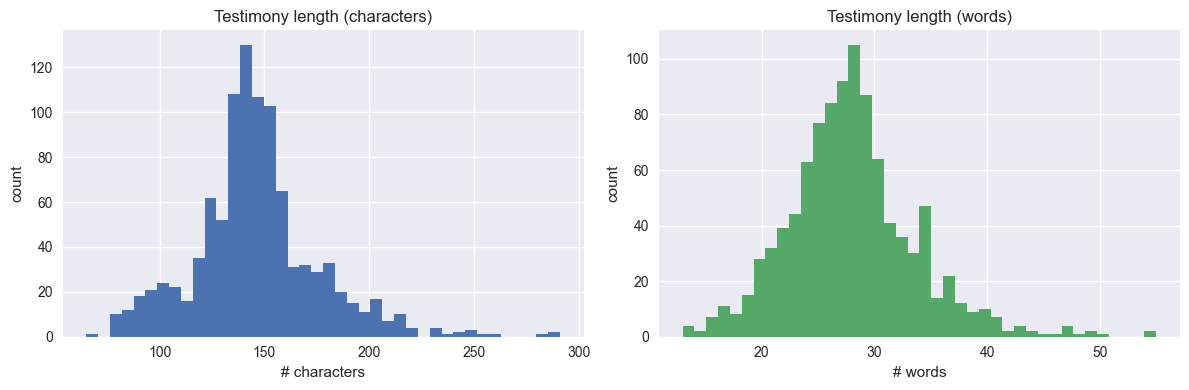

Saved: figures/eda_lengths_boxplot.png


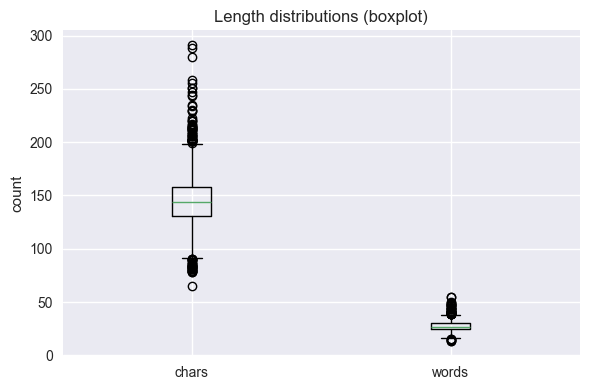

Saved: figures/eda_id_vs_nwords.png


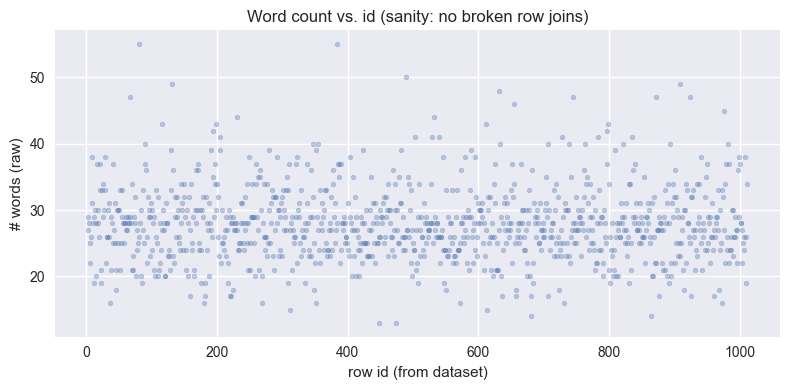

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_eda["n_chars"], bins=40, color="#4C72B0")
axes[0].set_title("Testimony length (characters)")
axes[0].set_xlabel("# characters")
axes[0].set_ylabel("count")

axes[1].hist(df_eda["n_words"], bins=40, color="#55A868")
axes[1].set_title("Testimony length (words)")
axes[1].set_xlabel("# words")
axes[1].set_ylabel("count")

plt.tight_layout()
save_current_fig("eda_lengths.png")
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
ax2.boxplot(
    [df_eda["n_chars"].to_numpy(), df_eda["n_words"].to_numpy()],
    tick_labels=["chars", "words"],
)
ax2.set_title("Length distributions (boxplot)")
ax2.set_ylabel("count")
plt.tight_layout()
save_current_fig("eda_lengths_boxplot.png")
plt.show()

fig3, ax3 = plt.subplots(1, 1, figsize=(8, 4))
ax3.scatter(df_eda["id"], df_eda["n_words"], alpha=0.35, s=12, c="#4C72B0")
ax3.set_xlabel("row id (from dataset)")
ax3.set_ylabel("# words (raw)")
ax3.set_title("Word count vs. id (sanity: no broken row joins)")
plt.tight_layout()
save_current_fig("eda_id_vs_nwords.png")
plt.show()


### Additional EDA (quality checks)

**CSV / testimony field**: After the optional `0xRRGGBB` column, `csv.reader` may split an **unquoted** testimony on commas. We rejoin those fields with commas so the testimony text is restored to a single string (quoted testimonies stay one field). Together with **`int(str(row[0]).strip())`** for ids, this keeps one row per testimony.

We also check:
- missing `color` rate
- duplicates before cleaning
- frequent tokens (CountVectorizer with the same extended stop list as downstream TF‑IDF)


Rows: 1010
Missing color rate: 0.392
Exact duplicates on raw text: 9
Saved: figures/eda_color_presence.png


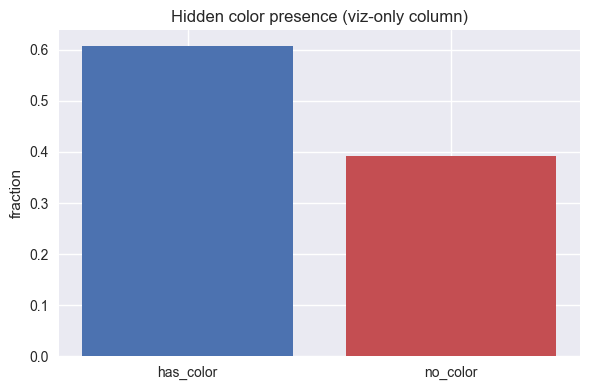

Saved: figures/eda_top_tokens.png


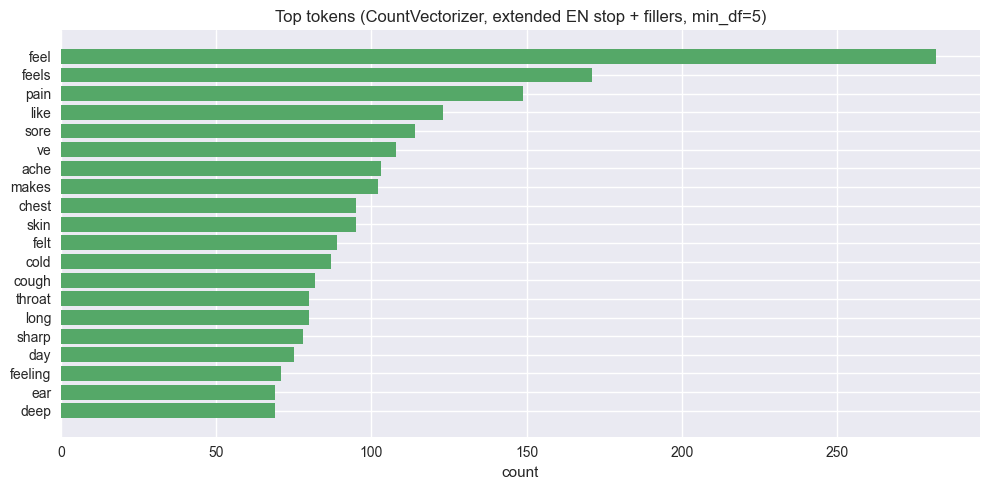

In [6]:
missing_color_rate = float(df_raw["color"].isna().mean())
dup_raw = int(df_raw.duplicated(subset=["testimony_raw"]).sum())
print(f"Rows: {len(df_raw)}")
print(f"Missing color rate: {missing_color_rate:.3f}")
print(f"Exact duplicates on raw text: {dup_raw}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(["has_color", "no_color"], [1 - missing_color_rate, missing_color_rate], color=["#4C72B0", "#C44E52"])
ax.set_title("Hidden color presence (viz-only column)")
ax.set_ylabel("fraction")
plt.tight_layout()
save_current_fig("eda_color_presence.png")
plt.show()

# Token frequency (simple sanity-check) using sklearn CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words=STOP_WORDS, min_df=5)
X_counts = cv.fit_transform(df_raw["testimony_raw"].astype(str).tolist())
counts = np.asarray(X_counts.sum(axis=0)).ravel()
terms = np.array(cv.get_feature_names_out())
top_idx = np.argsort(counts)[::-1][:20]
top_terms = terms[top_idx]
top_counts = counts[top_idx]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.barh(top_terms[::-1], top_counts[::-1], color="#55A868")
ax.set_title("Top tokens (CountVectorizer, extended EN stop + fillers, min_df=5)")
ax.set_xlabel("count")
plt.tight_layout()
save_current_fig("eda_top_tokens.png")
plt.show()


## 3) Cleaning / normalization

We apply conservative, explainable cleaning steps:

- **Lowercasing** and normalising common Unicode punctuation to ASCII quotes/dashes.
- **Remove punctuation** (commas, periods, etc.) by mapping it to spaces so word tokens match sklearn’s English stop list. Without this, attached punctuation (e.g. word + comma) can prevent stop-word removal from working as intended.
- **Keep apostrophe** for contractions before vectorization.
- **Collapse whitespace**.

This keeps TF‑IDF + `stop_words` behaviour **auditable** and aligned with the EDA token counts above.


In [7]:
def normalise_text(text: str) -> str:
    cleaned = str(text).lower()
    cleaned = (
        cleaned.replace("’", "'")
        .replace("“", '"')
        .replace("”", '"')
        .replace("–", "-")
        .replace("—", "-")
    )
    cleaned = re.sub(r"[^a-z0-9\s']", " ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned


df_clean = df_raw.copy()
df_clean["testimony_clean"] = df_clean["testimony_raw"].map(normalise_text)

# Remove empty and very short entries (parameterized)
MIN_LEN = 5
df_clean = df_clean[df_clean["testimony_clean"].str.len() > 0]
df_clean = df_clean[df_clean["testimony_clean"].str.len() >= MIN_LEN]

# Remove exact duplicates (based on cleaned text)
dup_before = df_clean.duplicated(subset=["testimony_clean"]).sum()
df_clean = df_clean.drop_duplicates(subset=["testimony_clean"]).reset_index(drop=True)

dup_before, df_clean.shape


(np.int64(17), (993, 4))

In [8]:
df_clean[["id", "color", "testimony_raw", "testimony_clean"]].head(8)


,id,color,testimony_raw,testimony_clean
0,2,0x000000,"The feverish feeling eased, but I’m now breath...",the feverish feeling eased but i'm now breathi...
1,3,0x000000,"While working in the garden, I touched a metal...",while working in the garden i touched a metal ...
2,4,NaN,A short sprint brought on a twinge in the midd...,a short sprint brought on a twinge in the midd...
3,5,0x000000,I accidentally left my hand on a hot mug for a...,i accidentally left my hand on a hot mug for a...
4,6,NaN,A sudden twist while reaching for a bag made o...,a sudden twist while reaching for a bag made o...
5,7,0x000000,"During a birthday party, a hot beverage was kn...",during a birthday party a hot beverage was kno...
6,8,NaN,I noticed a rash on my forearms after handling...,i noticed a rash on my forearms after handling...
7,9,0x000000,"Since I lost 20 pounds, my headaches have less...",since i lost 20 pounds my headaches have lesse...


## 4) Save cleaned dataset

We save a cleaned CSV that will be used by the modeling notebook.

- Output: `unsupervised/cleaned_unsupervised_dataset.csv`
- Kept columns: `id`, `color` (viz only), `testimony_raw`, `testimony_clean`


In [9]:
OUT_PATH = Path("cleaned_unsupervised_dataset.csv")
# Write a strict CSV so downstream parsing is reliable even when testimonies contain commas/quotes.
# This keeps the pipeline reproducible when re-running notebooks.
df_export = df_clean.copy()
df_export.columns = df_export.columns.astype(str).str.strip()
df_export.to_csv(
    OUT_PATH,
    index=False,
    quoting=csv.QUOTE_ALL,
    escapechar="\\",
    lineterminator="",
)
OUT_PATH.resolve()


PosixPath('/Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/unsupervised/cleaned_unsupervised_dataset.csv')